In [1]:
import ultralytics
print(ultralytics.__version__)

8.4.42


In [2]:
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())

2.11.0+cpu
CUDA available: False


In [8]:
# importing all the libraries i need for training
# torch helps me detect if i have a gpu available
# YOLO is the model i'm using for oil palm detection
# Path makes it easier to handle file paths on windows

import torch
from ultralytics import YOLO
from pathlib import Path

print('All libraries imported successfully!')
print(f'GPU available: {torch.cuda.is_available()}')  # tells me if gpu can be used

All libraries imported successfully!
GPU available: False


In [9]:
# defining all the important folder locations so i dont have to 
# type the full path every time i need it

MOPAD_DIR  = Path(r'C:\Users\nia.insyirah\mopad_dataset')  # where my dataset is
MODELS_DIR = Path(r'C:\Users\nia.insyirah\models')          # where i want to save my trained model

data_yaml  = MOPAD_DIR / 'data.yaml'                        # the file that tells yolo about my dataset

# double check everything exists before starting
print(f'Dataset folder exists : {MOPAD_DIR.exists()}')
print(f'data.yaml exists      : {data_yaml.exists()}')
print(f'Train images          : {len(list((MOPAD_DIR / "train" / "images").glob("*.jpg")))}')
print(f'Val images            : {len(list((MOPAD_DIR / "valid" / "images").glob("*.jpg")))}')

Dataset folder exists : True
data.yaml exists      : True
Train images          : 1803
Val images            : 500


In [5]:
# before training i want to see how balanced my dataset is
# this tells me how many trees of each class i have
# if one class has way fewer examples the model might struggle to learn it

from collections import Counter

labels_dir   = MOPAD_DIR / 'train' / 'labels'
class_counts = Counter()

# go through every label file and count how many of each class
for label_file in labels_dir.glob('*.txt'):
    for line in label_file.read_text().splitlines():
        parts = line.strip().split()
        if parts:
            class_counts[int(parts[0])] += 1

# class names based on the corrected mopad labels
ID_TO_CLASS = {0: 'Dead', 1: 'Healthy', 2: 'Small', 3: 'Yellow'}

print('Class distribution in my training set:')
total = sum(class_counts.values())
for class_id, count in sorted(class_counts.items()):
    name  = ID_TO_CLASS[class_id]
    ratio = count / total * 100
    print(f'  {name:10s} (class {class_id}): {count:6,} instances ({ratio:.1f}%)')

Class distribution in my training set:
  Dead       (class 0):    234 instances (0.2%)
  Healthy    (class 1): 90,389 instances (76.1%)
  Small      (class 2): 26,644 instances (22.4%)
  Yellow     (class 3):  1,473 instances (1.2%)


In [6]:
# load yolov8n (nano) which is already pretrained on coco dataset
# coco has 80 different object classes so the model already knows
# basic shapes, edges, and how to detect objects in general
# i'm just going to fine tune it specifically for oil palm trees
# this is called transfer learning - faster and better than training from scratch

print('Loading YOLOv8n pretrained model...')
yolo_model = YOLO('yolov8n.pt')
print('Model loaded successfully!')

Loading YOLOv8n pretrained model...
Model loaded successfully!


## Cell5 Model Training

optimization: (adjust parameter to minimize or maximize function like error or loss so model learns
pattern from data effectively
- achieves better performance

yolo by default is using SDG (Stochastic Gradient Descent) by default it comes with learning rate at 0.01
final learning rate 0.01, momentum 0.937, weight decay 0.0005 

- if sdg, dia nya model parameters are initialized randomly

  2. adam (Adaptive Moment Estimation)
 - combine momentum and adaptive learning rates to adjust learning rate
 - Adam  effective for tasks with large datasets and complex models due to its ability to adapt learning rates and reduce oscillations
- . It requires minimal hyperparameter tuning
- difference between AdamW and adam
-adamw sesuai w deep learning like cnn

# cls = 2.0 loss weighting
- default is 0.5,  we use 2.0 so like it forces the model to take dead and yellow srsly eventho theyre rare
- 
     



In [ ]:
# this is the main training cell - it will take a while to run
# yolo will go through all 1803 images 50 times
# each time it gets better at detecting Dead, Healthy, Small and Yellow trees

print('Starting YOLOv8 training on MOPAD dataset.')

results = yolo_model.train(
    data     = str(data_yaml),               # my dataset config file
    epochs   = 50,                           # go through all images 50 times
    imgsz    = 640,                          # resize images to 640x640 pixels
    batch    = 16,                           # process 16 images at a time
    patience = 15,                           # stop early if no improvement for 15 epochs (prevents overfitting)
    lr0      = 0.01,                         # starting learning rate (controls how fast model updates)
    lrf      = 0.01,                         # final learning rate - (slows down near the end)
    cls      = 2.0,     #classification loss weight   # penalise class mistakes more - (helps model learn rare Dead class)
    dropout  = 0.1,                          # randomly ignore 10% of connections - (forces model to generalise better)
    project  = str(MODELS_DIR),             # save everything here
    name     = 'yolo_mopad',                # name of this folder
    exist_ok = True,                         # okay to reuse folder if it exists
    device   = 0 if torch.cuda.is_available() else 'cpu'  # use gpu if i have one, otherwise cpu
)

print('Training complete!')
print(f'My best model is saved at: {results.save_dir}/weights/best.pt')

Starting YOLOv8 training on MOPAD dataset.
New https://pypi.org/project/ultralytics/8.4.48 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.42  Python-3.13.9 torch-2.11.0+cpu CPU (11th Gen Intel Core i5-1145G7 @ 2.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\nia.insyirah\mopad_dataset\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train,

In [ ]:
test_results = eval_model.val(
    data  = str(data_yaml),
    split = 'test',
    imgsz = 640,
)

In [ ]:
model = YOLO('runs/detect/train/weights/last.pt')
model.train(resume=True)

In [ ]:
# Cell 1 - clear GPU
import torch
torch.cuda.empty_cache()

In [1]:
from ultralytics import YOLO
import torch

In [2]:

model = YOLO('runs/detect/train/weights/best.pt')

FileNotFoundError: [Errno 2] No such file or directory: 'runs\\detect\\train\\weights\\best.pt'

In [3]:
# Cell 2 - resume
from ultralytics import YOLO
model = YOLO('runs/detect/train/weights/last.pt')
model.train(resume=True)

FileNotFoundError: [Errno 2] No such file or directory: 'runs\\detect\\train\\weights\\last.pt'

In [5]:
import os

for root, dirs, files in os.walk('/'):
    for file in files:
        if file.endswith('.pt'):
            print(os.path.join(root, file))

/Users\nia.insyirah\yolov8n.pt
/Users\nia.insyirah\AppData\Local\anaconda3\Lib\site-packages\tests\tmp\runs\detect\models\yolo_oil_palm\weights\best.pt
/Users\nia.insyirah\AppData\Local\anaconda3\Lib\site-packages\tests\tmp\runs\detect\models\yolo_oil_palm\weights\last.pt
/Users\nia.insyirah\AppData\Local\anaconda3\pkgs\protego-0.4.0-py313haa95532_0\info\test\tests\test_data\up.pt
/Users\nia.insyirah\AppData\Local\anaconda3\pkgs\protego-0.4.0-py313haa95532_0\info\test\tests\test_data\www.cp.pt
/Users\nia.insyirah\AppData\Local\Programs\Git\usr\share\vim\vim92\tutor\tutor1.pt
/Users\nia.insyirah\models\yolo_mopad\weights\best.pt
/Users\nia.insyirah\models\yolo_mopad\weights\last.pt
/Users\nia.insyirah\Videos\runs\detect\palm_tree_detector3\weights\best.pt
/Users\nia.insyirah\Videos\runs\detect\palm_tree_detector3\weights\last.pt


In [10]:
print(MODELS_DIR)

C:\Users\nia.insyirah\models


In [11]:
import os
path = os.path.join(MODELS_DIR, 'yolo_mopad', 'weights')
print(os.listdir(path))

['best.pt', 'last.pt']


In [20]:
best_model_path = r'C:\Users\nia.insyirah\models\yolo_mopad\weights\best.pt'
eval_model = YOLO(best_model_path)

test_results = eval_model.val(
    data  = str(data_yaml),
    split = 'val',
    imgsz = 640,
)

Ultralytics 8.4.42  Python-3.13.9 torch-2.11.0+cpu CPU (11th Gen Intel Core i5-1145G7 @ 2.60GHz)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 54.021.4 MB/s, size: 386.7 KB)
val: Scanning C:\Users\nia.insyirah\mopad_dataset\valid\labels.cache... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 46.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 2.6s/it 1:242.4sss
                   all        500      32846      0.993      0.991      0.994      0.907
                  Dead         51         61      0.996          1      0.995      0.924
               Healthy        482      24979      0.995      0.992      0.995      0.915
                 Small        458       7395      0.995      0.977      0.995      0.872
                Yellow        234        411      0.984      0.995      0.993      0.916
Speed: 1.7ms pr

In [15]:
print(data_yaml)

C:\Users\nia.insyirah\mopad_dataset\data.yaml


In [19]:
import yaml
with open(r'C:\Users\nia.insyirah\mopad_dataset\data.yaml') as f:
    print(yaml.safe_load(f))

{'train': 'C:/Users/nia.insyirah/mopad_dataset/train/images', 'val': 'C:/Users/nia.insyirah/mopad_dataset/valid/images', 'nc': 4, 'names': ['Dead', 'Healthy', 'Small', 'Yellow']}


In [21]:
best_model_path = r'C:\Users\nia.insyirah\models\yolo_mopad\weights\best.pt'
eval_model = YOLO(best_model_path)

test_results = eval_model.val(
    data  = r'C:\Users\nia.insyirah\mopad_dataset\data.yaml',
    split = 'val',
    imgsz = 640,
)

Ultralytics 8.4.42  Python-3.13.9 torch-2.11.0+cpu CPU (11th Gen Intel Core i5-1145G7 @ 2.60GHz)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 68.512.5 MB/s, size: 391.6 KB)
val: Scanning C:\Users\nia.insyirah\mopad_dataset\valid\labels.cache... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 3.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 2.6s/it 1:222.6sss
                   all        500      32846      0.993      0.991      0.994      0.907
                  Dead         51         61      0.996          1      0.995      0.924
               Healthy        482      24979      0.995      0.992      0.995      0.915
                 Small        458       7395      0.995      0.977      0.995      0.872
                Yellow        234        411      0.984      0.995      0.993      0.916
Speed: 1.8ms pre

In [22]:
results = model.predict(
    source = r'C:\Users\nia.insyirah\mopad_dataset\valid\images\your_image.jpg',
    imgsz  = 640,
    conf   = 0.25,
    save   = True,
    show   = True,  # pops up a window to see it immediately
)

NameError: name 'model' is not defined

In [23]:
from ultralytics import YOLO

model = YOLO(r'C:\Users\nia.insyirah\models\yolo_mopad\weights\best.pt')

# Test on a single image
results = model.predict(
    source = r'C:\Users\nia.insyirah\mopad_dataset\valid\images',  # or a single image path
    imgsz  = 640,
    conf   = 0.25,  # confidence threshold
    save   = True,  # saves output images with boxes drawn
)


image 1/500 C:\Users\nia.insyirah\mopad_dataset\valid\images\44000_16000_1013_87.jpg: 640x640 92 Healthys, 5 Smalls, 209.7ms
image 2/500 C:\Users\nia.insyirah\mopad_dataset\valid\images\44000_16000_1027_1541.jpg: 640x640 101 Healthys, 4 Smalls, 208.0ms
image 3/500 C:\Users\nia.insyirah\mopad_dataset\valid\images\44000_16000_1059_3696.jpg: 640x640 82 Healthys, 9 Smalls, 149.2ms
image 4/500 C:\Users\nia.insyirah\mopad_dataset\valid\images\44000_16000_1060_351.jpg: 640x640 90 Healthys, 7 Smalls, 140.7ms
image 5/500 C:\Users\nia.insyirah\mopad_dataset\valid\images\44000_16000_1067_1756.jpg: 640x640 90 Healthys, 4 Smalls, 123.6ms
image 6/500 C:\Users\nia.insyirah\mopad_dataset\valid\images\44000_16000_1075_3609.jpg: 640x640 79 Healthys, 10 Smalls, 136.0ms
image 7/500 C:\Users\nia.insyirah\mopad_dataset\valid\images\44000_16000_1090_3244.jpg: 640x640 73 Healthys, 10 Smalls, 1 Yellow, 141.0ms
image 8/500 C:\Users\nia.insyirah\mopad_dataset\valid\images\44000_16000_1141_2026.jpg: 640x640 76 H

In [24]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os

model = YOLO(r'C:\Users\nia.insyirah\models\yolo_mopad\weights\best.pt')

# pick a random image from val
img_folder = r'C:\Users\nia.insyirah\mopad_dataset\valid\images'
img_file = os.listdir(img_folder)[0]  # just grab the first image
img_path = os.path.join(img_folder, img_file)

# run prediction
results = model.predict(source=img_path, imgsz=640, conf=0.25)

# show the image with boxes
annotated = results[0].plot()  # draws boxes on image
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(annotated_rgb)
plt.axis('off')
plt.title(f'Predictions: {img_file}')
plt.show()


image 1/1 C:\Users\nia.insyirah\mopad_dataset\valid\images\44000_16000_1013_87.jpg: 640x640 92 Healthys, 5 Smalls, 151.9ms
Speed: 10.3ms preprocess, 151.9ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


<Figure size 1200x800 with 1 Axes>


image 1/1 C:\Users\nia.insyirah\mopad_dataset\valid\images\44000_16000_1013_87.jpg: 640x640 92 Healthys, 5 Smalls, 110.2ms
Speed: 9.6ms preprocess, 110.2ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 640)


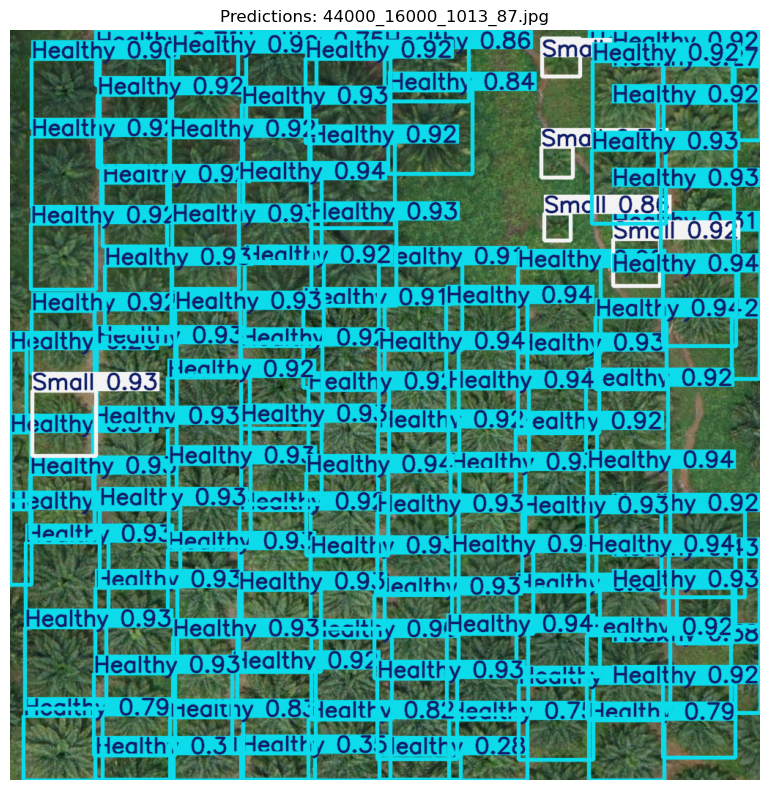

In [26]:
%matplotlib inline

from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os

model = YOLO(r'C:\Users\nia.insyirah\models\yolo_mopad\weights\best.pt')

img_folder = r'C:\Users\nia.insyirah\mopad_dataset\valid\images'
img_file = os.listdir(img_folder)[0]
img_path = os.path.join(img_folder, img_file)

results = model.predict(source=img_path, imgsz=640, conf=0.25)

annotated = results[0].plot()
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.close('all')
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(annotated_rgb)
ax.axis('off')
ax.set_title(f'Predictions: {img_file}')
plt.tight_layout()
plt.show()

In [2]:
from ultralytics import YOLO

model = YOLO(r'C:\Users\nia.insyirah\models\yolo_mopad\weights\best.pt')

results = model.predict(
    source = r'C:\Users\nia.insyirah\OneDrive - SD Guthrie\Documents\OCR\original.jpg',
    imgsz  = 640,
    conf   = 0.25,
)

# print confidence for every detected tree
for r in results:
    for box in r.boxes:
        cls_name = r.names[int(box.cls[0])]
        conf     = float(box.conf[0]) * 100
        print(f'{cls_name}: {conf:.1f}% confident')


image 1/1 C:\Users\nia.insyirah\OneDrive - SD Guthrie\Documents\OCR\original.jpg: 640x640 81 Healthys, 9 Smalls, 155.2ms
Speed: 9.3ms preprocess, 155.2ms inference, 3.3ms postprocess per image at shape (1, 3, 640, 640)
Healthy: 95.1% confident
Healthy: 94.5% confident
Healthy: 94.4% confident
Healthy: 94.2% confident
Healthy: 94.1% confident
Healthy: 94.0% confident
Small: 93.8% confident
Healthy: 93.8% confident
Healthy: 93.7% confident
Small: 93.6% confident
Healthy: 93.5% confident
Small: 93.5% confident
Healthy: 93.5% confident
Healthy: 93.5% confident
Healthy: 93.5% confident
Healthy: 93.4% confident
Small: 93.3% confident
Small: 93.3% confident
Small: 93.2% confident
Healthy: 93.1% confident
Healthy: 93.0% confident
Healthy: 92.9% confident
Healthy: 92.9% confident
Healthy: 92.7% confident
Healthy: 92.7% confident
Healthy: 92.7% confident
Healthy: 92.5% confident
Healthy: 92.5% confident
Healthy: 92.4% confident
Healthy: 92.3% confident
Small: 92.3% confident
Healthy: 92.3% conf

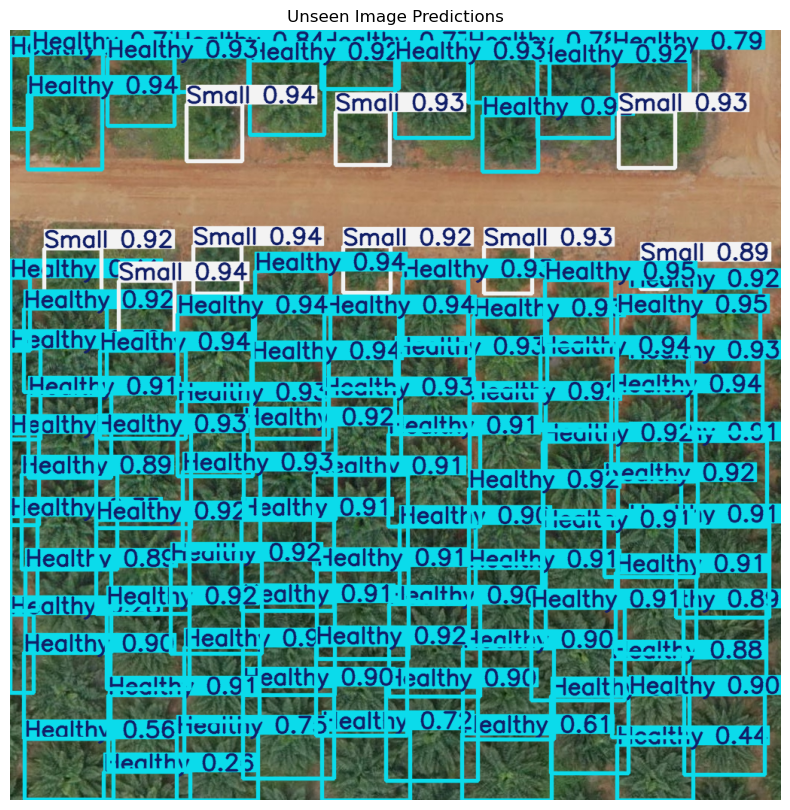

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import cv2

annotated = results[0].plot()
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 10))
plt.imshow(annotated_rgb)
plt.axis('off')
plt.title('Unseen Image Predictions')
plt.show()